# 7. Modelado con PySpark

Sección 9.10.4.5 del enunciado. Se ajustan los mismos seis modelos con `pyspark.ml.classification`,
usando exclusivamente `ParamGridBuilder` + `CrossValidator(numFolds=3)` y
`BinaryClassificationEvaluator(metricName="areaUnderROC")` como criterio de selección. Los datos
permanecen en DataFrames de Spark de principio a fin; solo después de entrenar y predecir se
transfieren al driver las columnas `id`, `default` y la puntuación del conjunto de prueba, y ese
tiempo se reporta aparte.

El umbral de decisión se elige con el mismo criterio que en scikit-learn (Youden en
entrenamiento, con la misma rejilla de 999 cuantiles, constante `PROBS` de `src/evaluacion.py`),
pero calculado con agregaciones distribuidas: al driver solo llegan los cuantiles y los conteos
por cubeta.

In [1]:
import sys
import time
import warnings

sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import features as fe
import modelado as mo
import spark_utils as su
import utils as u
from pyspark.ml.classification import (DecisionTreeClassifier, GBTClassifier, LinearSVC,
                                       LogisticRegression, NaiveBayes, RandomForestClassifier)
from pyspark.ml.tuning import ParamGridBuilder

u.estilo()
pd.set_option("display.max_columns", 30, "display.width", 180)

## 7.1 Sesión de Spark con la configuración obligatoria

La sesión se crea con los parámetros exigidos por el enunciado. En modo local (`local[*]`, un
solo proceso JVM con 10 hilos de ejecución) el driver y el ejecutor comparten memoria, de modo que
la memoria efectiva es `spark.driver.memory = 8g`; `spark.executor.memory` se fija por fidelidad
al enunciado pero no tiene efecto en este modo.

In [2]:
spark = su.sesion_spark()
spark.sparkContext.setCheckpointDir(str(u.MODELOS / "checkpoints"))
print("Spark", spark.version, "| master:", spark.sparkContext.master,
      "| paralelismo por defecto:", spark.sparkContext.defaultParallelism)
for k in su.CONFIG_OBLIGATORIA:
    print(f"  {k} = {spark.conf.get(k)}")
print("Equipo:", u.hardware())

Spark 4.2.0 | master: local[*] | paralelismo por defecto: 400
  spark.sql.shuffle.partitions = 400
  spark.default.parallelism = 400
  spark.executor.memory = 8g
  spark.driver.memory = 8g
  spark.memory.fraction = 0.8
  spark.memory.storageFraction = 0.3
Equipo: {'sistema': 'Darwin 27.0.0', 'python': '3.11.16', 'nucleos_logicos': 10, 'cpu': 'Apple M5', 'nucleos_rendimiento': '4', 'nucleos_eficiencia': '6', 'ram_gb': 24.0}


## 7.2 Preprocesamiento y caché

Mismo flujo del capítulo 5: lectura del CSV completo, variables, unión con la partición común,
`filter` por `split`, `Pipeline` ajustado con entrenamiento y `persist(MEMORY_AND_DISK)` del
resultado del `VectorAssembler`.

**Particiones de los datos.** El CSV comprimido llega en una sola partición (gzip no es
divisible), así que hay que reparticionarlo. La sesión conserva `spark.sql.shuffle.partitions` =
400 y `spark.default.parallelism` = 400, que gobiernan las uniones y agregaciones, pero los
conjuntos de entrenamiento y prueba cacheados se reparten en **40 particiones** (4 por núcleo).
El enunciado admite parámetros "equivalentes debidamente justificados", y la justificación es
medible: cada pasada de un algoritmo iterativo lanza una tarea por partición, y con 400 particiones
de unas 2.700 filas cada tarea dedica más tiempo a su programación y a reservar y combinar los
histogramas de los árboles que a procesar datos. Las 400 particiones están pensadas para un
clúster con cientos de núcleos; la guía de ajuste de Spark recomienda de 2 a 3 tareas por núcleo,
y se usan 4 (40 particiones) para equilibrar la carga entre los núcleos de rendimiento y los de
eficiencia. El capítulo 11 mide el efecto con el conjunto completo: con 400 particiones, la
validación cruzada de la regresión logística tarda 319 s frente a 140 s con 40, y la del árbol,
808 s frente a 70 s.

`CrossValidator` se usa con `parallelism=1` (su valor por defecto): cada ajuste ya reparte su
trabajo entre las 40 particiones y los 10 hilos de ejecución, de modo que entrenar varias
combinaciones a la vez no añade núcleos, solo compite por la misma memoria. El capítulo 11 mide
el efecto de `parallelism=3`.

In [3]:
t0 = time.time()
datos = su.preparar_spark(spark)
datos["base"].unpersist()   # la base intermedia ya no se necesita: queda en caché solo lo ensamblado
t_preproc = time.time() - t0
train, test = datos["train"], datos["test"]
print(f"Preprocesamiento + caché: {t_preproc:.1f} s")
print(f"Entrenamiento: {datos['n_train']:,} | prueba: {datos['n_test']:,} | "
      f"particiones: {train.rdd.getNumPartitions()} | dimensión: {len(datos['nombres'])}")
print("Nivel de almacenamiento:", train.storageLevel)
u.guardar_json({"t_preprocesamiento_s": t_preproc, "n_train": datos["n_train"],
                "n_test": datos["n_test"], "particiones": train.rdd.getNumPartitions()},
               u.RESULTADOS / "spark_preprocesamiento.json")
resultados = {}
PARALELISMO = 1   # CrossValidator: combinaciones de la rejilla que se entrenan a la vez
print("Modo de prueba de humo activo:", bool(u.FRACCION_PRUEBA))

Preprocesamiento + caché: 34.5 s
Entrenamiento: 1,078,447 | prueba: 269,612 | particiones: 40 | dimensión: 72
Nivel de almacenamiento: Disk Memory Serialized 1x Replicated
Modo de prueba de humo activo: False


## 7.3 Regresión logística

L2 pura (`elasticNetParam=0`), `regParam` ∈ {1e-6, 1e-5, 1e-4} y `standardization=False`, porque
las variables ya llegan escaladas y así la penalización actúa sobre los mismos coeficientes que
en scikit-learn (sección 6.2).

In [4]:
lr = LogisticRegression(featuresCol="features", labelCol="label", elasticNetParam=0.0,
                        standardization=False, maxIter=100, family="binomial")
grid = ParamGridBuilder().addGrid(lr.regParam, mo.REG_PARAMS).build()
resultados["LogisticRegression"] = mo.ajustar_spark("LogisticRegression", lr, grid, datos,
                                                    paralelismo=PARALELISMO)
pd.read_csv(u.RESULTADOS / "spark" / "LogisticRegression_cv.csv")

,regParam,mean_test_score,std_test_score
0,0.000001,0.716582,0.000468
1,0.000010,0.716584,0.000467
2,0.000100,0.716593,0.000463


Igual que en scikit-learn, la regularización no cambia el AUC (0,71658 a 0,71659) y se elige
$\lambda = 10^{-4}$. L-BFGS converge en 39 iteraciones de las 100 permitidas. Los dos entornos
llegan a modelos prácticamente equivalentes: el AUC de prueba coincide hasta la cuarta cifra
decimal (0,7171), aunque el umbral de Youden (0,1906 frente a 0,1926) y las métricas que dependen
de él difieren levemente.

## 7.4 Árbol de decisión

Spark discretiza cada variable continua en a lo sumo `maxBins` = 32 intervalos (valor por
defecto, que se conserva) cuyos cortes se estiman con cuantiles de una muestra; scikit-learn
evalúa todos los cortes posibles. El efecto de esta diferencia se mide en el capítulo 11.

In [5]:
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", maxBins=32, seed=u.SEMILLA)
grid = ParamGridBuilder().addGrid(dt.maxDepth, [5, 10, 15]).build()
resultados["DecisionTree"] = mo.ajustar_spark("DecisionTree", dt, grid, datos, paralelismo=PARALELISMO)
pd.read_csv(u.RESULTADOS / "spark" / "DecisionTree_cv.csv")

,maxDepth,mean_test_score,std_test_score
0,5,0.651425,0.002517
1,10,0.701637,0.000716
2,15,0.672479,0.000399


La profundidad elegida es la misma que en scikit-learn (10) y su AUC de validación casi igual
(0,7016 frente a 0,7024). Donde los entornos se separan es a profundidad 5: 0,651 en Spark frente
a 0,695 en scikit-learn. El capítulo 11 muestra que la causa no es la discretización (`maxBins`),
sino la **poda**: Spark une las hojas hermanas que predicen la misma clase y, como casi todas
predicen "pagado", un árbol de profundidad 5 queda con 6 hojas en lugar de 32 y pierde resolución
en las probabilidades.

## 7.5 Bosque aleatorio

Variables candidatas por nodo: scikit-learn usa $\lfloor\sqrt{72}\rfloor = 8$, mientras que
`featureSubsetStrategy="sqrt"` de Spark redondea hacia arriba ($\lceil\sqrt{72}\rceil = 9$). Para
igualarlos se fija el número explícito `"8"`. El muestreo bootstrap no es idéntico: Spark lo
aproxima con pesos Poisson(1) por fila y scikit-learn extrae una muestra multinomial exacta.
`cacheNodeIds=True` (con puntos de control cada 10 iteraciones) solo cambia cómo se recorre el
árbol en cada pasada sobre los datos, no el modelo resultante.

In [6]:
n_cand = str(int(np.sqrt(len(datos["nombres"]))))
print("Variables candidatas por nodo:", n_cand)
rf = RandomForestClassifier(featuresCol="features", labelCol="label", featureSubsetStrategy=n_cand,
                            subsamplingRate=1.0, bootstrap=True, maxBins=32, seed=u.SEMILLA,
                            cacheNodeIds=True, checkpointInterval=10)
grid = (ParamGridBuilder().addGrid(rf.numTrees, [10, 50, 100])
        .addGrid(rf.maxDepth, [5, 10, 15]).build())
resultados["RandomForest"] = mo.ajustar_spark("RandomForest", rf, grid, datos, paralelismo=PARALELISMO)
pd.read_csv(u.RESULTADOS / "spark" / "RandomForest_cv.csv")

Variables candidatas por nodo: 8


,numTrees,maxDepth,mean_test_score,std_test_score
0,10,5,0.633047,0.007220
1,10,10,0.707154,0.000272
2,10,15,0.706165,0.000469
3,50,5,0.686328,0.009660
4,50,10,0.711900,0.000305
5,50,15,0.716540,0.000341
6,100,5,0.697286,0.002537
7,100,10,0.712519,0.000408
8,100,15,0.718009,0.000328


La mejor combinación coincide con la de scikit-learn (100 árboles de profundidad 15) y su AUC es
algo menor (0,7180 frente a 0,7192). Con árboles poco profundos la diferencia es mayor: 10
árboles de profundidad 5 dan 0,633 en Spark y 0,703 en scikit-learn, otra vez por la poda de
hojas con la misma clase (capítulo 11). A esa profundidad los resultados de Spark también varían
mucho más entre pliegues (desviación de 0,007 a 0,010 con 10 y 50 árboles, frente a menos de
0,0005 a profundidades 10 y 15). El entrenamiento con validación cruzada (incluido el reajuste
final) tomó 2.254 s, diez veces más que en scikit-learn (215 s).

## 7.6 Gradient boosting

`GBTClassifier` con tasa de aprendizaje (`stepSize`) fija en 0,1, `maxIter` ∈ {50, 100} y
`maxDepth` ∈ {3, 5}. Con el mismo número de árboles y la misma profundidad, los dos algoritmos no
ajustan exactamente el mismo modelo: `GradientBoostingClassifier` asigna a cada hoja un paso de
Newton (cociente entre la suma de residuos y la suma de $p(1-p)$), mientras que Spark ajusta
árboles de regresión a los gradientes de la pérdida logística con etiquetas en $\{-1, +1\}$ y usa
la media de la hoja como valor. Además, Spark discretiza las variables (`maxBins`) y ajusta su
primer árbol directamente a las etiquetas, mientras que scikit-learn parte de una predicción
inicial constante igual al logaritmo de la razón de momios de la clase positiva.

In [7]:
gbt = GBTClassifier(featuresCol="features", labelCol="label", stepSize=0.1, subsamplingRate=1.0,
                    featureSubsetStrategy="all", maxBins=32, seed=u.SEMILLA,
                    cacheNodeIds=True, checkpointInterval=10)
grid = (ParamGridBuilder().addGrid(gbt.maxIter, [50, 100])
        .addGrid(gbt.maxDepth, [3, 5]).build())
resultados["GradientBoosting"] = mo.ajustar_spark("GradientBoosting", gbt, grid, datos,
                                                  paralelismo=PARALELISMO)
pd.read_csv(u.RESULTADOS / "spark" / "GradientBoosting_cv.csv")

,maxIter,maxDepth,mean_test_score,std_test_score
0,50,3,0.714512,0.000557
1,50,5,0.718492,0.000571
2,100,3,0.718633,0.000459
3,100,5,0.722103,0.000659


La combinación elegida (100 iteraciones, profundidad 5) y el AUC (0,7221 en validación) son
prácticamente los de scikit-learn (0,7231). Es, con diferencia, el modelo más lento en Spark:
8.805 s (2,4 horas). Cada iteración del boosting depende de la anterior, y cada una exige varias
pasadas distribuidas sobre el millón de filas (una por nivel del árbol más la actualización de
las predicciones). Cada pasada paga el costo fijo de programar las tareas y combinar los
histogramas.

## 7.7 SVM lineal

`LinearSVC` de Spark minimiza la pérdida *hinge* con regularización L2. La puntuación es el
segundo elemento de `rawPrediction` ($w^\top x + b$).

In [8]:
svc = LinearSVC(featuresCol="features", labelCol="label", standardization=False, maxIter=100)
grid = ParamGridBuilder().addGrid(svc.regParam, mo.REG_PARAMS).build()
resultados["LinearSVC"] = mo.ajustar_spark("LinearSVC", svc, grid, datos, usa_raw=True,
                                           paralelismo=PARALELISMO)
pd.read_csv(u.RESULTADOS / "spark" / "LinearSVC_cv.csv")

,regParam,mean_test_score,std_test_score
0,0.000001,0.649939,0.017346
1,0.000010,0.595888,0.027677
2,0.000100,0.645616,0.008676


El SVM de Spark sí ordena los préstamos (AUC de validación entre 0,60 y 0,65), a diferencia del
de scikit-learn (cercano a 0,5). La explicación no es que Spark resuelva mejor el problema, sino
que lo resuelve de forma menos exacta: su optimizador está limitado a 100 iteraciones (`maxIter`)
y su solución queda cerca de la trivial en escala (el umbral de Youden es −1,0000, como en
scikit-learn; en el capítulo 11, $\lVert w \rVert$ = 0,046 y $b$ = −1,026), pero la dirección de
$w$ conserva información útil que la solución de `liblinear` no tiene. La inestabilidad entre
pliegues (desviaciones de hasta 0,028) es coherente con una solución detenida a medio camino. (La
API de Spark no expone el número de iteraciones de `LinearSVC`, así que no se pudo registrar.)

## 7.8 Naive Bayes gaussiano

`NaiveBayes(modelType="gaussian")`: las variantes multinomial y de Bernoulli de Spark no admiten
los valores negativos que produce el escalado. La rejilla vacía de `ParamGridBuilder` contiene
una sola configuración, así que `CrossValidator` hace la validación cruzada y el reajuste final,
igual que en scikit-learn.

In [9]:
nb = NaiveBayes(featuresCol="features", labelCol="label", modelType="gaussian")
grid = ParamGridBuilder().build()
resultados["NaiveBayes"] = mo.ajustar_spark("NaiveBayes", nb, grid, datos, paralelismo=PARALELISMO)
pd.read_csv(u.RESULTADOS / "spark" / "NaiveBayes_cv.csv")

,mean_test_score,std_test_score
0,0.65249,0.002461


Naive Bayes gaussiano tiene solución cerrada (medias y varianzas por clase) y da el mismo AUC de
prueba (0,6525) y las mismas métricas con umbral en ambos entornos. En validación cruzada la
diferencia es mínima (0,6525 frente a 0,6526) porque los pliegues no son idénticos.

## 7.9 Resumen de métricas

Las métricas de clasificación y el AUC ROC se calcularon de forma distribuida (agregaciones y
`BinaryClassificationEvaluator` con `numBins=0`, es decir, sin agrupar puntuaciones). El AUC-PR
se reporta con la definición de precisión promedio de scikit-learn, calculada sobre las
puntuaciones transferidas, para que sea comparable entre entornos; el `areaUnderPR` de Spark usa
interpolación trapezoidal y se conserva en los archivos de resultados (`auc_pr_spark`).

In [10]:
tabla = pd.DataFrame([mo.resumen(resultados[m]) for m in mo.ORDEN])
tabla.insert(0, "mejores parámetros", [str(resultados[m]["mejores_parametros"]) for m in mo.ORDEN])
tabla.round(4)

,mejores parámetros,AUC CV,AUC prueba,AUC-PR,Accuracy,Precision,Recall,F1,umbral,t_cv (s),t_pred (s)
LogisticRegression,{'regParam': 0.0001},0.7166,0.7171,0.3817,0.6441,0.3169,0.6759,0.4315,0.1906,113.6721,0.2843
DecisionTree,{'maxDepth': 10},0.7016,0.7014,0.3577,0.6380,0.3085,0.6542,0.4193,0.1999,59.9478,0.2115
RandomForest,"{'numTrees': 100, 'maxDepth': 15}",0.7180,0.7181,0.3859,0.6833,0.3380,0.6101,0.4350,0.2201,2253.7996,61.2364
GradientBoosting,"{'maxIter': 100, 'maxDepth': 5}",0.7221,0.7228,0.3930,0.6547,0.3240,0.6704,0.4369,0.1980,8805.1269,0.6321
LinearSVC,{'regParam': 1e-06},0.6499,0.6436,0.3253,0.6548,0.3006,0.5487,0.3884,-1.0000,224.6004,0.2049
NaiveBayes,{},0.6525,0.6525,0.2953,0.6199,0.2898,0.6220,0.3954,0.2115,37.7316,0.3231


El orden de los seis modelos es idéntico al de scikit-learn: gradient boosting (0,7228), bosque
(0,7181), regresión logística (0,7171), árbol (0,7014), Naive Bayes (0,6525) y SVM (0,6436). El SVM
queda último en ambos entornos, aunque en Spark su AUC es mucho mayor que el 0,5391 de
scikit-learn, por la razón explicada en 7.7. Los
umbrales de Youden y las métricas dependientes del umbral también son casi iguales a los de
scikit-learn (F1 entre 0,42 y 0,44 en los cuatro mejores modelos).

In [11]:
defecto = pd.DataFrame({m: {k: resultados[m]["metricas_defecto"][k]
                            for k in ["umbral", "accuracy", "precision", "recall", "f1"]}
                        for m in mo.ORDEN}).T
defecto.round(4)

,umbral,accuracy,precision,recall,f1
LogisticRegression,0.5,0.8028,0.5381,0.0914,0.1563
DecisionTree,0.5,0.8014,0.5237,0.0668,0.1184
RandomForest,0.5,0.8027,0.6183,0.0322,0.0612
GradientBoosting,0.5,0.8042,0.5603,0.0928,0.1593
LinearSVC,0.0,0.8002,0.0000,0.0000,0.0000
NaiveBayes,0.5,0.6967,0.3186,0.4549,0.3747


Con el umbral por defecto se repite lo observado en scikit-learn: exactitud de 0,80 con recall
de 3 % a 9 % en los modelos de árbol y en la regresión logística.

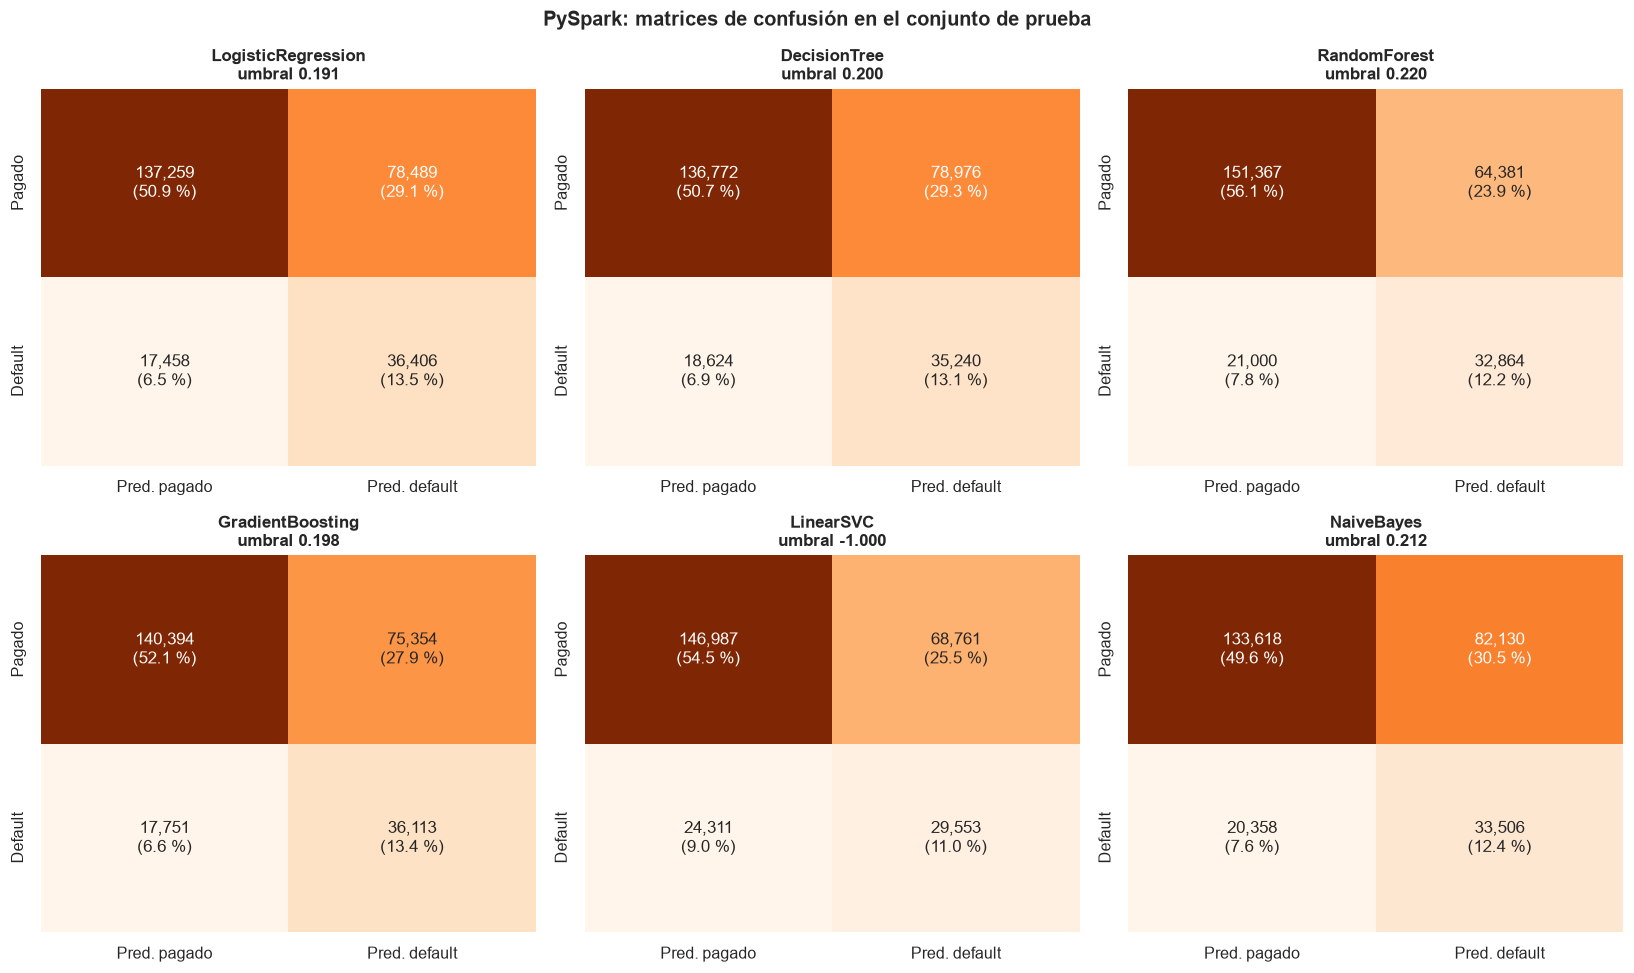

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, m in zip(axes.ravel(), mo.ORDEN):
    r = resultados[m]["metricas_youden"]
    cm = np.array([[r["tn"], r["fp"]], [r["fn"], r["tp"]]])
    sns.heatmap(cm, annot=np.array([[f"{v:,}\n({100 * v / cm.sum():.1f} %)" for v in fila] for fila in cm]),
                fmt="", cmap="Oranges", cbar=False, ax=ax,
                xticklabels=["Pred. pagado", "Pred. default"], yticklabels=["Pagado", "Default"])
    ax.set_title(f"{m}\numbral {resultados[m]['umbral_youden']:.3f}")
fig.suptitle("PySpark: matrices de confusión en el conjunto de prueba", fontsize=13, weight="bold")
fig.tight_layout()
u.guardar_fig(fig, "07_confusion_spark")
plt.show()

### Tiempos

In [13]:
tiempos = pd.DataFrame({m: {"entrenamiento + CV (s)": resultados[m]["t_entrenamiento_cv_s"],
                            "predicción (s)": resultados[m]["t_prediccion_s"],
                            "transferencia al driver (s)": resultados[m]["t_transferencia_s"],
                            "ajustes": resultados[m]["n_ajustes"]} for m in mo.ORDEN}).T
tiempos.loc["Total"] = tiempos.sum()
print(f"Preprocesamiento + caché: {t_preproc:.1f} s")
print("Iteraciones del modelo final (límite):",
      {m: (resultados[m]["iteraciones"], resultados[m]["max_iter"]) for m in mo.ORDEN
       if resultados[m]["iteraciones"] is not None})
tiempos.round(2)

Preprocesamiento + caché: 34.5 s
Iteraciones del modelo final (límite): {'LogisticRegression': (39, 100)}


,entrenamiento + CV (s),predicción (s),transferencia al driver (s),ajustes
LogisticRegression,113.67,0.28,0.15,10.0
DecisionTree,59.95,0.21,0.13,10.0
RandomForest,2253.80,61.24,54.54,28.0
GradientBoosting,8805.13,0.63,0.09,13.0
LinearSVC,224.60,0.20,0.16,10.0
NaiveBayes,37.73,0.32,0.16,4.0
Total,11494.88,62.89,55.24,75.0


El entrenamiento con validación cruzada de los seis modelos tomó 11.495 s (3,2 horas), 5,8 veces
lo que tardó scikit-learn (1.967 s). El gradient boosting concentra el 77 % de ese tiempo. Dos
cifras del bosque destacan: la predicción tardó 61 s y la transferencia 55 s, frente a menos de
1 s en los demás modelos. Una explicación plausible es el tamaño del modelo (100 árboles de
profundidad 15; 39 MB al guardarlo en disco), que Spark debe serializar y enviar a cada tarea
dentro de la función de predicción, más que el cálculo mismo. Que la transferencia tarde casi lo
mismo sugiere que
las predicciones, aunque persistidas, se recalcularon al transferirlas (Spark puede desalojar
bloques de la caché cuando necesita memoria); en ese caso el costo es otra vez el del envío del
modelo y no el de mover 269.612 filas al driver, que en los demás modelos toma 0,1-0,2 s.

### Verificación: métricas distribuidas frente a métricas locales

Con las puntuaciones transferidas se recalculan las métricas con scikit-learn. Deben coincidir
con las calculadas en Spark.

In [14]:
import evaluacion as ev

punt = mo.leer_puntuaciones("spark")
ver = []
for m in mo.ORDEN:
    loc = ev.metricas(punt["default"], punt[m], resultados[m]["umbral_youden"])
    dis = resultados[m]["metricas_youden"]
    ver.append({"modelo": m, "AUC Spark": dis["auc_roc"], "AUC local": loc["auc_roc"],
                "F1 Spark": dis["f1"], "F1 local": loc["f1"], "TP Spark": dis["tp"], "TP local": loc["tp"]})
pd.DataFrame(ver).set_index("modelo").round(6)

,AUC Spark,AUC local,F1 Spark,F1 local,TP Spark,TP local
modelo,,,,,,
LogisticRegression,0.717097,0.717097,0.431456,0.431456,36406,36406
DecisionTree,0.701410,0.701410,0.419324,0.419324,35240,35240
RandomForest,0.718149,0.718149,0.434971,0.434971,32864,32864
GradientBoosting,0.722832,0.722832,0.436857,0.436857,36113,36113
LinearSVC,0.643567,0.643567,0.388400,0.388400,29553,29553
NaiveBayes,0.652508,0.652508,0.395351,0.395351,33506,33506


Las métricas calculadas de forma distribuida coinciden exactamente con las recalculadas
localmente sobre las puntuaciones transferidas: el AUC hasta la sexta cifra decimal y los
conteos de verdaderos positivos sin diferencia.

In [15]:
train.unpersist()
test.unpersist()
spark.stop()